# Customer Churn & Retention Analysis

## Project Objective

Analyze customer churn patterns to identify the customer segments and factors associated with higher churn, evaluate the business impact of churn, and provide data-driven recommendations to improve customer retention.

In [1]:
## Import libraries for data manipulation, numerical analysis, visualization, and statistical testing 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
## Load the customer churn dataset into a Pandas DataFrame

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 2. Data Understanding

The dataset contains customer-level information including demographics, services, contract details, payment methods, tenure, monthly charges, total charges, and churn status.

In [3]:
## Check the number of customers and attributes in the dataset

df.shape

(7043, 21)

In [4]:
## Preview the first five records to understand the structure and values of the dataset

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Display all column names to understand the available customer attributes

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
# Inspect data types, non-null counts, and overall dataset structure

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Data Cleaning

The dataset was checked for missing values, duplicate records, incorrect data types, and inconsistent categorical values before performing analysis.

In [7]:
# Check whether the dataset contains duplicate customer records

df.duplicated().sum()

np.int64(0)

In [8]:
# Check the least frequent TotalCharges values
df["TotalCharges"].value_counts().tail(10)

TotalCharges
2625.25    1
6886.25    1
1495.1     1
743.3      1
1419.4     1
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, dtype: int64

In [9]:
# Inspect TotalCharges values to identify unusual or potentially invalid entries

df["TotalCharges"].value_counts().tail(10)

TotalCharges
2625.25    1
6886.25    1
1495.1     1
743.3      1
1419.4     1
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, dtype: int64

In [10]:
# Convert TotalCharges from text to numeric values and treat invalid entries as missing values

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
# Check how many missing values were created after converting TotalCharges to numeric

df["TotalCharges"].isna().sum()

np.int64(11)

In [12]:
# Examine the customer records where TotalCharges is missing

df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [13]:
# Replace missing TotalCharges values with zero because these customers have zero months of tenure

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [14]:
# Verify that TotalCharges no longer contains missing values

df["TotalCharges"].isna().sum()

np.int64(0)

In [15]:
# Confirm that TotalCharges is now stored as a numeric column

df["TotalCharges"].dtype

dtype('float64')

In [16]:
# Check for missing values across all columns after data cleaning

df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
# Inspect unique values in categorical columns to identify categories and possible inconsistencies

for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet 

/var/folders/cs/bx35qn657bjb2sh3bhnt2kgc0000gn/T/ipykernel_5418/625811045.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [18]:
# Check categorical columns for values containing only whitespace

for col in df.select_dtypes(include="object").columns:
    spaces = df[col].astype(str).str.contains(r"^\s|\s$", regex=True).sum()
    if spaces > 0:
        print(col, spaces)

/var/folders/cs/bx35qn657bjb2sh3bhnt2kgc0000gn/T/ipykernel_5418/2267711650.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


## 4. Exploratory Data Analysis (EDA)

Explore customer churn patterns across customer demographics, services, contracts, tenure, payment methods, and monthly charges.

In [19]:
#EDA 

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [20]:
#churn rate.
churn_rate = (df["Churn"] == "Yes").mean() * 100
churn_rate

np.float64(26.536987079369588)

In [21]:
#Calculate retention rate

retention_rate = (df["Churn"] == "No").mean() * 100
retention_rate

np.float64(73.4630129206304)

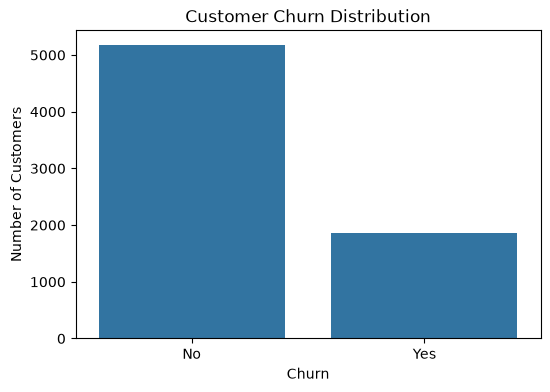

In [22]:
# Create a figure with a width of 6 inches and height of 4 inches
plt.figure(figsize=(6, 4))

# Create a count plot to show the number of customers in each churn category
sns.countplot(data=df, x="Churn")

# Add a title to the chart
plt.title("Customer Churn Distribution")

# Label the X-axis
plt.xlabel("Churn")

# Label the Y-axis
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

In [23]:
#Are customers on certain contract types more likely to leave?

# 1) Calculate churn rate by contract
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


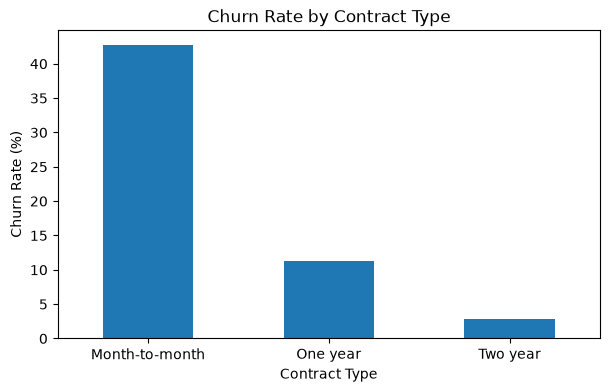

In [24]:
#create a chart specifically showing the churn percentage

contract_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.savefig("../output/figures/churn_rate_by_contract.png", dpi=300, bbox_inches="tight")

plt.show()



In [25]:
# 2) Does tenure affect churn?

# Compare the tenure of customers who churned vs. customers who stayed
df.groupby("Churn")["tenure"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Churn,,,,
No,37.569965,38.0,0,72
Yes,17.979133,10.0,1,72


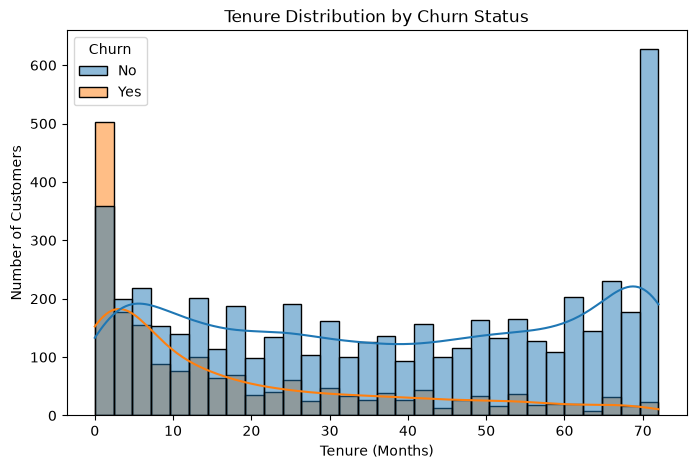

In [26]:
#Visualize tenure

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [27]:
#Does Monthly Charge affect churn?

df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Churn,,,,
No,61.265124,64.425,18.25,118.75
Yes,74.441332,79.650,18.85,118.35


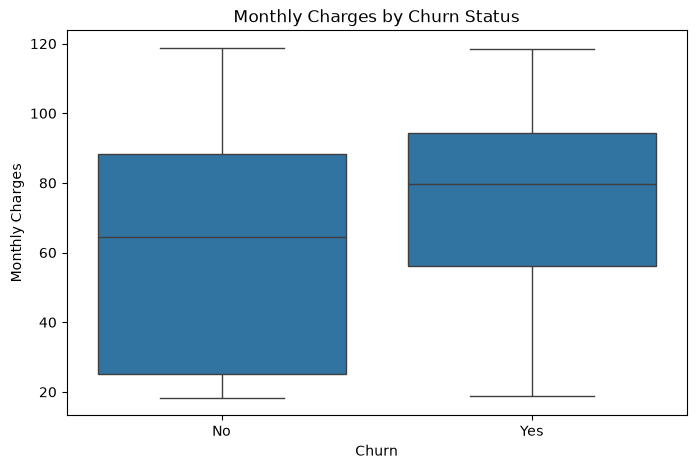

In [28]:
#VISUALISE MONTHLY CHARGE

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [29]:
#Does the type of internet service a customer uses relate to churn?

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


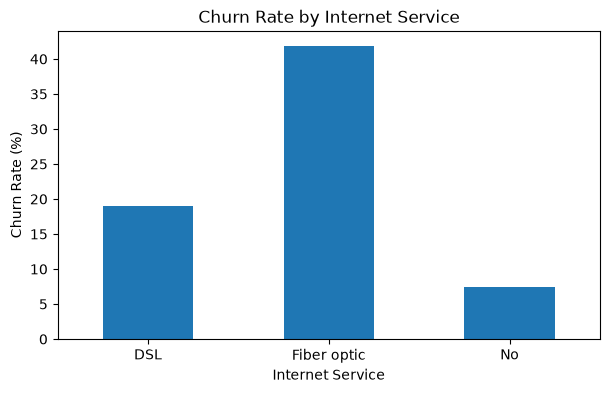

In [30]:
# Visualize churn rate by internet service type
internet_churn["Yes"].plot(kind="bar", figsize=(7, 4))

# Add chart title
plt.title("Churn Rate by Internet Service")

# Label the X-axis
plt.xlabel("Internet Service")

# Label the Y-axis
plt.ylabel("Churn Rate (%)")

# Keep category labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [31]:
#Does Tech Support relate to churn?

techsupport_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [32]:


#Payment Method

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

#So customers using electronic check are much more likely to churn than customers using automatic payment methods.

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


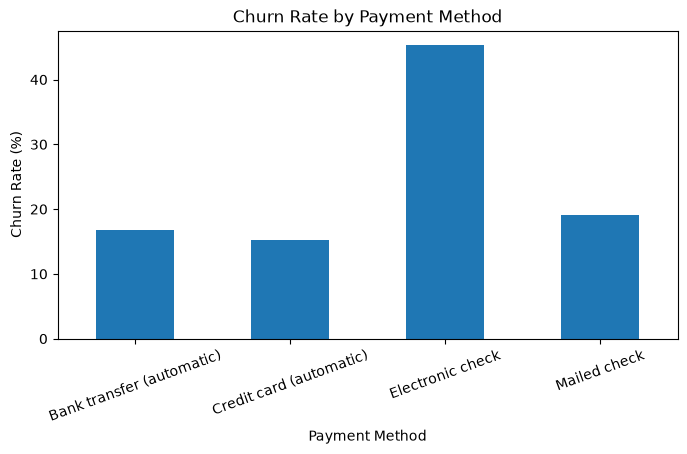

In [33]:
# Visualize churn rate by payment method
payment_churn["Yes"].plot(kind="bar", figsize=(8, 4))

# Add chart title
plt.title("Churn Rate by Payment Method")

# Label the X-axis
plt.xlabel("Payment Method")

# Label the Y-axis
plt.ylabel("Churn Rate (%)")

# Rotate labels slightly for better readability
plt.xticks(rotation=20)

# Save the chart as a high-resolution PNG file
plt.savefig(
    "../output/figures/churn_rate_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

## 5. Statistical Analysis

Statistical tests are used to determine whether the observed relationships between customer characteristics and churn are statistically significant.

In [34]:
# Statistical test: Check whether Contract Type and Churn are related

# Create a contingency table showing Contract Type vs Churn
contract_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

# Perform a Chi-square test of independence
# This checks whether the difference in churn across contract types
# is statistically significant
chi2, p_value, dof, expected = stats.chi2_contingency(contract_table)

# Display the test results
print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673393e-258


In [35]:
# Statistical test: Check whether Payment Method and Churn are related

# Create a contingency table showing Payment Method vs Churn
payment_table = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

# Perform Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(payment_table)

# Display the test results
print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 648.1423274814
p-value: 3.6823546520098007e-140


In [36]:
# Statistical test: Check whether Monthly Charges differ between churned and retained customers

# Select monthly charges for customers who churned
churned_charges = df[df["Churn"] == "Yes"]["MonthlyCharges"]

# Select monthly charges for customers who stayed
not_churned_charges = df[df["Churn"] == "No"]["MonthlyCharges"]

# Perform an independent two-sample t-test
# equal_var=False is used because the two groups may have different variances
t_stat, p_value = stats.ttest_ind(
    churned_charges,
    not_churned_charges,
    equal_var=False
)

# Display the test results
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 18.407526676414673
p-value: 8.592449331547065e-73


## 6. KPI Analysis

Calculate key business metrics to quantify customer retention, customer value, and the revenue impact associated with churn.

In [37]:
# KPI: Average monthly charge per customer

# Calculate the average monthly amount paid by customers
avg_monthly_charge = df["MonthlyCharges"].mean()

# Display the KPI
print("Average Monthly Charge: $", round(avg_monthly_charge, 2))

Average Monthly Charge: $ 64.76


In [38]:
# Retention rate

retention_rate = 100 - churn_rate

print("Retention Rate:", round(retention_rate, 2), "%")

Retention Rate: 73.46 %


In [39]:
# Average monthly charge

avg_monthly_charge = df["MonthlyCharges"].mean()

print("Average Monthly Charge:", round(avg_monthly_charge, 2))

Average Monthly Charge: 64.76


In [40]:
# Average customer tenure

avg_tenure = df["tenure"].mean()

print("Average Customer Tenure:", round(avg_tenure, 2), "months")

Average Customer Tenure: 32.37 months


In [41]:
# KPI: Total revenue associated with churned customers

# Select customers who have churned
churned_revenue = df[df["Churn"] == "Yes"]["TotalCharges"]

# Add their total charges
churned_revenue = churned_revenue.sum()

# Display the KPI
print("Revenue Associated with Churn: $", round(churned_revenue, 2))

Revenue Associated with Churn: $ 2862926.9


In [42]:
# Calculate the monthly charges associated with customers who churned
revenue_at_risk = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

# Display the KPI
print("Monthly Charges Associated with Churned Customers: $", round(revenue_at_risk, 2))

Monthly Charges Associated with Churned Customers: $ 139130.85


## 7. Key Business Insights & Recommendations

Based on the EDA, statistical analysis, and KPI analysis, the following findings and recommendations were identified.

In [43]:
# Churn rate by contract type

contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

# Key Business Insights

| Finding | Evidence | Business Implication |
|---|---|---|
| Month-to-month customers have the highest churn | 42.71% churn vs 11.27% for one-year and 2.83% for two-year contracts | Encourage customers to move toward longer-term contracts |
| Churn is concentrated among newer customers | Median tenure is 10 months for churned customers vs 38 months for retained customers | Focus retention efforts on customers during their first year |
| Fiber optic customers have higher churn | 41.89% churn vs 18.96% for DSL customers | Investigate pricing, service quality, and customer experience |
| Electronic check users have the highest churn | 45.29% churn rate | Investigate payment experience and encourage alternative payment methods |
| Churned customers have higher monthly charges | Median monthly charge of $79.65 vs $64.43 for retained customers | Prioritize higher-value customers in retention campaigns |
| Contract type is statistically associated with churn | Chi-square test p-value < 0.05 | Contract structure is a significant factor associated with churn |
| Payment method is statistically associated with churn | Chi-square test p-value < 0.05 | Payment method should be considered when designing retention strategies |
| Monthly charges differ significantly by churn status | t-test p-value < 0.05 | Pricing/customer value should be considered in churn analysis |

# Business Recommendations

### 1. Reduce month-to-month churn
Target month-to-month customers with retention offers and incentives to move toward one-year or two-year contracts.

### 2. Strengthen early customer retention
Focus onboarding and proactive support on customers during their first year, when churn risk is higher.

### 3. Investigate fiber optic churn
Analyze pricing, service quality, and customer experience for fiber optic customers to understand their higher churn rate.

### 4. Improve payment experience
Investigate the high churn associated with electronic check payments and encourage customers to adopt alternative payment methods.

### 5. Prioritize high-value customers
Customers with higher monthly charges represent greater potential revenue impact, so retention campaigns can prioritize these segments.

### 6. Monitor retention KPIs
Regularly track churn rate, retention rate, contract mix, tenure, and monthly charges to identify emerging churn patterns.

## 8. Correlation Analysis

In [44]:
# Convert the Churn column from text values into numerical values
# "No" = 0 means the customer did not churn
# "Yes" = 1 means the customer churned

df["Churn_Encoded"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [45]:
# Display the first 5 rows to verify that the new Churn_Encoded column was created
df[["Churn", "Churn_Encoded"]].head()

,Churn,Churn_Encoded
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [46]:
# Select the numerical variables we want to compare
correlation_data = df[
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn_Encoded"]
]

# Calculate the correlation between each pair of variables
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
correlation_matrix

,tenure,MonthlyCharges,TotalCharges,Churn_Encoded
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn_Encoded,-0.352229,0.193356,-0.198324,1.000000


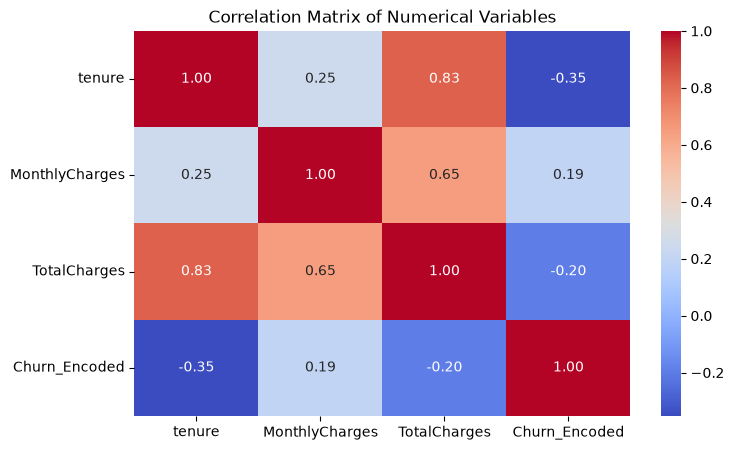

In [47]:
# Create a figure for the correlation heatmap
plt.figure(figsize=(8, 5))

# Display the correlation values using colors
# annot=True shows the numerical correlation values
# fmt=".2f" displays values up to 2 decimal places
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Add a title to the heatmap
plt.title("Correlation Matrix of Numerical Variables")

# Display the heatmap
plt.show()

## 9. Logistic Regression — Churn Prediction

In [48]:
# Select the customer features that will be used to predict churn
X = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "InternetService",
        "PaymentMethod",
        "TechSupport",
        "OnlineSecurity",
        "SeniorCitizen"
    ]
]

# Define Churn as the target variable we want to predict
# "No" = 0 and "Yes" = 1
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [49]:
# Display the first 5 rows of the selected features
X.head()

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,TechSupport,OnlineSecurity,SeniorCitizen
0,1,29.85,29.85,Month-to-month,DSL,Electronic check,No,No,0
1,34,56.95,1889.50,One year,DSL,Mailed check,No,Yes,0
2,2,53.85,108.15,Month-to-month,DSL,Mailed check,No,Yes,0
3,45,42.30,1840.75,One year,DSL,Bank transfer (automatic),Yes,Yes,0
4,2,70.70,151.65,Month-to-month,Fiber optic,Electronic check,No,No,0


In [50]:
# Import tools for preprocessing numerical and categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define the numerical features
# These will be standardized using only the training data later
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

# Define the categorical features
# These will be converted into numerical columns using one-hot encoding
categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity"
]

# Create the preprocessing transformer
# StandardScaler handles numerical features
# OneHotEncoder handles categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ), categorical_features)
    ]
)

In [ ]:
# Import the function used to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the features and target into training and testing datasets
# 80% of the data will be used for training
# 20% will be used for testing
# random_state=42 makes the split reproducible
# stratify=y keeps the same churn proportion in both datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Display the number of rows and columns in the training features
X_train.shape


(5634, 9)

In [ ]:
# Display the number of rows and columns in the testing features
X_test.shape

(1409, 9)

In [ ]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create a pipeline that first preprocesses the data
# and then trains the Logistic Regression model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

In [ ]:
# Train the Logistic Regression model using the training data
# X_train contains the customer features
# y_train contains whether each customer churned (0) or did not churn (1)
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['tenure','MonthlyCharges','TotalCharges',...,'TechSupport', 'OnlineSecurity','SeniorCitizen']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [ ]:
# Use the trained model to predict whether each test customer will churn
# The model returns either 0 (No Churn) or 1 (Churn)
y_pred = model.predict(X_test)

# Display the first 10 predictions
y_pred[:10]

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 0])

In [ ]:
# Import the accuracy_score function from scikit-learn
from sklearn.metrics import accuracy_score

# Calculate the percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)

# Display the model's accuracy
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 79.77%


In [ ]:
# Import precision, recall, and F1-score metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision
# Of the customers predicted to churn, how many actually churned?
precision = precision_score(y_test, y_pred)

# Calculate recall
# Of the customers who actually churned, how many did the model identify?
recall = recall_score(y_test, y_pred)

# Calculate F1-score
# F1-score balances precision and recall
f1 = f1_score(y_test, y_pred)

# Display all three metrics
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")

Precision: 63.95%
Recall: 54.55%
F1 Score: 58.87%


In [ ]:
# Import the Pipeline tool used to combine preprocessing and the model
from sklearn.pipeline import Pipeline

# Import Logistic Regression for churn prediction
from sklearn.linear_model import LogisticRegression

# Create the final leakage-safe machine learning pipeline
# Preprocessing is fitted only on the training data
# The Logistic Regression model then uses the processed features
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# Train the complete pipeline using only the training data
model_pipeline.fit(X_train, y_train)

# Calculate the probability of churn for each test customer
# The second column represents the probability of Churn = 1
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

# Display the first 10 churn probabilities
y_prob[:10]

array([0.04572899, 0.57798229, 0.07200168, 0.51355484, 0.01716091,
       0.52479237, 0.4288263 , 0.09940251, 0.00409496, 0.44966208])

In [ ]:
# Split the original training data into a smaller training set and validation set
# The validation set will be used only to choose the best probability threshold
# No preprocessing is performed before this split
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Display the sizes of the new training and validation sets
print("Training set:", X_train_new.shape)
print("Validation set:", X_val.shape)

Training set: (4507, 9)
Validation set: (1127, 9)


In [ ]:
# Create a validation pipeline using the same preprocessing as the final model
# The categorical columns will be one-hot encoded
# The numerical columns will be standardized
# Logistic Regression will then use the processed features
validation_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# Train the validation pipeline only on the new training data
validation_model.fit(X_train_new, y_train_new)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['tenure','MonthlyCharges','TotalCharges',...,'TechSupport', 'OnlineSecurity','SeniorCitizen']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [ ]:
# Calculate the probability of churn for each validation customer
# [:, 1] selects the probability of the "Churn = 1" class
y_val_prob = validation_model.predict_proba(X_val)[:, 1]

# Display the first 10 churn probabilities
y_val_prob[:10]

array([0.31521744, 0.01591148, 0.06573667, 0.20687992, 0.29680117,
       0.05727994, 0.08405861, 0.02240171, 0.01631791, 0.19320422])

In [ ]:
# Import NumPy for numerical operations
import numpy as np

# Test several probability thresholds
thresholds = np.arange(0.30, 0.71, 0.05)

# Check how precision, recall, and F1-score change at each threshold
for threshold in thresholds:

    # Convert probabilities into 0/1 predictions using the current threshold
    y_val_pred = (y_val_prob >= threshold).astype(int)

    # Calculate evaluation metrics
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    # Display the results
    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2%} | "
        f"Recall: {recall:.2%} | "
        f"F1: {f1:.2%}"
    )

Threshold: 0.30 | Precision: 53.46% | Recall: 77.59% | F1: 63.30%
Threshold: 0.35 | Precision: 57.55% | Recall: 73.91% | F1: 64.71%
Threshold: 0.40 | Precision: 60.41% | Recall: 68.90% | F1: 64.38%
Threshold: 0.45 | Precision: 63.41% | Recall: 60.87% | F1: 62.12%
Threshold: 0.50 | Precision: 68.20% | Recall: 54.52% | F1: 60.59%
Threshold: 0.55 | Precision: 72.31% | Recall: 47.16% | F1: 57.09%
Threshold: 0.60 | Precision: 74.15% | Recall: 36.45% | F1: 48.88%
Threshold: 0.65 | Precision: 74.74% | Recall: 23.75% | F1: 36.04%
Threshold: 0.70 | Precision: 79.25% | Recall: 14.05% | F1: 23.86%


For this retention use case, the threshold was chosen to prioritize recall over precision because identifying more potential churners is more valuable than minimizing false alarms.

In [ ]:
# Apply the selected 0.35 probability threshold to the final test data
# Customers with a churn probability of 35% or more are classified as churners
y_test_pred_threshold = (y_prob >= 0.35).astype(int)

# Display the first 10 predictions
y_test_pred_threshold[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1])

In [ ]:
# Calculate the final evaluation metrics using the 0.35 threshold
# Precision tells us how many predicted churners actually churned
precision_threshold = precision_score(y_test, y_test_pred_threshold)

# Recall tells us how many actual churners the model successfully identified
recall_threshold = recall_score(y_test, y_test_pred_threshold)

# F1-score balances precision and recall
f1_threshold = f1_score(y_test, y_test_pred_threshold)

# Accuracy shows the overall percentage of correct predictions
accuracy_threshold = accuracy_score(y_test, y_test_pred_threshold)

# Display the final results
print(f"Accuracy: {accuracy_threshold:.2%}")
print(f"Precision: {precision_threshold:.2%}")
print(f"Recall: {recall_threshold:.2%}")
print(f"F1 Score: {f1_threshold:.2%}")

Accuracy: 77.08%
Precision: 55.19%
Recall: 72.46%
F1 Score: 62.66%


In [ ]:
# Calculate the accuracy of a simple majority-class baseline
# This represents always predicting the most common class
baseline_accuracy = y_test.value_counts(normalize=True).max()

# Calculate how much the model improves over the baseline
improvement = accuracy_threshold - baseline_accuracy

# Display the baseline and model improvement
print(f"Majority-Class Baseline Accuracy: {baseline_accuracy:.2%}")
print(f"Improvement Over Baseline: {improvement:.2%}")

Majority-Class Baseline Accuracy: 73.46%
Improvement Over Baseline: 3.62%


In [ ]:
# Import the confusion matrix function
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix using the final 0.35 threshold
cm = confusion_matrix(y_test, y_test_pred_threshold)

# Display the confusion matrix
print(cm)

[[815 220]
 [103 271]]


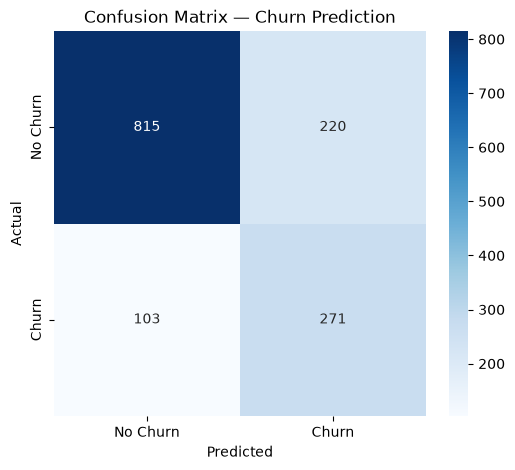

In [ ]:
# Create a figure for the confusion matrix
plt.figure(figsize=(6, 5))

# Display the confusion matrix as a heatmap
# annot=True shows the number of customers in each category
# fmt="d" displays the values as whole numbers
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

# Label the axes
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add a title
plt.title("Confusion Matrix — Churn Prediction")

# Display the plot
plt.show()

In [ ]:
# Get the feature names created by the preprocessing step
# This includes the numerical features and one-hot encoded categorical features
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get the logistic regression coefficients from the classifier inside the pipeline
coefficients = model_pipeline.named_steps["classifier"].coef_[0]

# Create a DataFrame containing each feature and its coefficient
# Positive coefficients are associated with higher predicted churn
# Negative coefficients are associated with lower predicted churn
feature_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Remove the preprocessing prefixes from the feature names
# This makes the output easier to read
feature_coefficients["Feature"] = (
    feature_coefficients["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Sort the features from strongest positive association to strongest negative association
feature_coefficients = feature_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

# Display the feature coefficients
feature_coefficients

,Feature,Coefficient
2,TotalCharges,0.577683
6,InternetService_Fiber optic,0.576950
9,PaymentMethod_Electronic check,0.444384
1,MonthlyCharges,0.187535
3,SeniorCitizen,0.090540
10,PaymentMethod_Mailed check,0.027285
8,PaymentMethod_Credit card (automatic),-0.036469
7,InternetService_No,-0.320452
11,TechSupport_No internet service,-0.320452
13,OnlineSecurity_No internet service,-0.320452


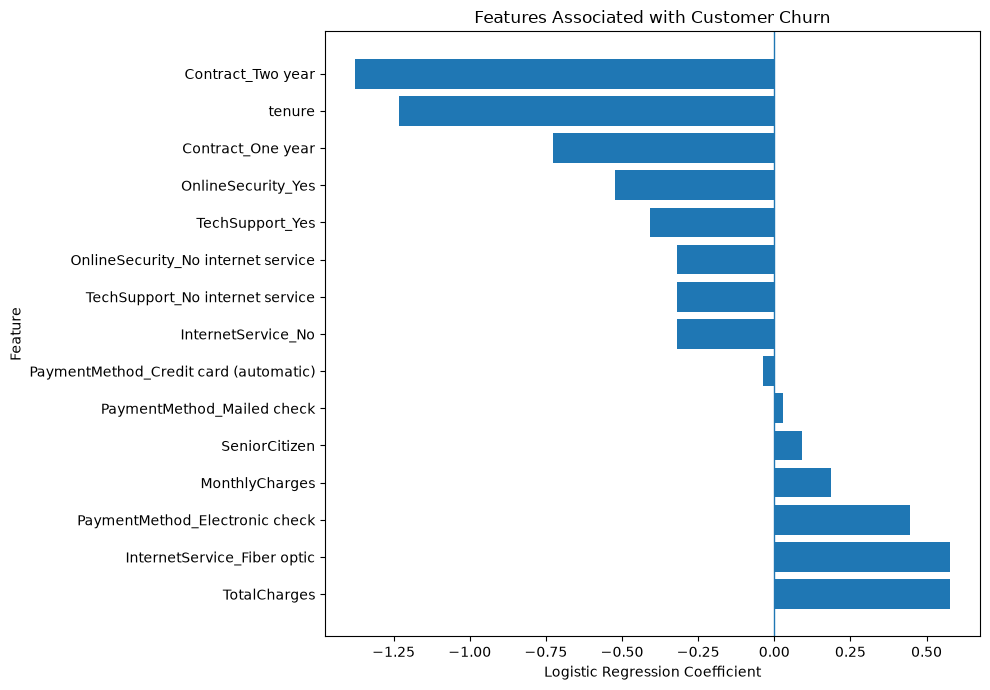

In [ ]:
# Create a horizontal bar chart of logistic regression coefficients
plt.figure(figsize=(10, 7))

# Plot each feature's coefficient
# Positive values indicate higher predicted churn
# Negative values indicate lower predicted churn
plt.barh(
    feature_coefficients["Feature"],
    feature_coefficients["Coefficient"]
)

# Add a vertical reference line at zero
# This separates positive and negative associations
plt.axvline(0, linewidth=1)

# Add labels and title
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Features Associated with Customer Churn")

# Adjust the layout so feature names are not cut off
plt.tight_layout()

# Display the chart
plt.show()

In [ ]:
# Create a copy of the test dataset so we can attach predictions to customers
risk_data = df.loc[X_test.index].copy()

# Add the model's predicted probability of churn
# This gives each customer a probability between 0 and 1
risk_data["Churn_Probability"] = y_prob

# Convert probabilities into practical customer risk categories
# Less than 35% = Low Risk
# 35% to 60% = Medium Risk
# More than 60% = High Risk
risk_data["Risk_Category"] = pd.cut(
    risk_data["Churn_Probability"],
    bins=[-float("inf"), 0.35, 0.60, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Display the first 10 customers with their churn probability and risk category
risk_data[
    ["customerID", "Churn_Probability", "Risk_Category"]
].head(10)

,customerID,Churn_Probability,Risk_Category
437,4376-KFVRS,0.045729,Low Risk
2280,2754-SDJRD,0.577982,Medium Risk
2235,9917-KWRBE,0.072002,Low Risk
4460,0365-GXEZS,0.513555,Medium Risk
3761,9385-NXKDA,0.017161,Low Risk
5748,4686-UXDML,0.524792,Medium Risk
3568,2227-JRSJX,0.428826,Medium Risk
2976,4830-FAXFM,0.099403,Low Risk
5928,1830-IPXVJ,0.004095,Low Risk
1639,4690-LLKUA,0.449662,Medium Risk


In [ ]:
# Count how many customers fall into each churn risk category
risk_counts = risk_data["Risk_Category"].value_counts()

# Display the number of customers in each risk category
risk_counts

Risk_Category
Low Risk       918
Medium Risk    289
High Risk      202
Name: count, dtype: int64

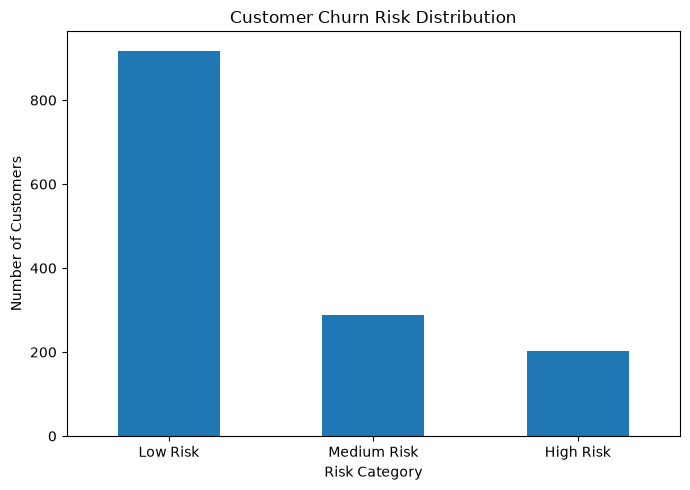

In [ ]:
# Count customers in each risk category
risk_counts = risk_data["Risk_Category"].value_counts()

# Create a bar chart showing the customer risk distribution
plt.figure(figsize=(7, 5))

# Plot the number of customers in each risk category
risk_counts.plot(kind="bar")

# Add labels and title
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Risk Distribution")

# Rotate category labels for better readability
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

## 10. Final Business Insights & Recommendations

### Key Business Insights

1. **Contract type is strongly associated with customer churn**
   - Month-to-month customers have substantially higher churn than customers on one-year or two-year contracts.
   - The logistic regression model also shows strong negative coefficients for one-year and two-year contracts, indicating lower predicted churn compared with the reference contract category.

2. **Fiber optic customers show elevated churn risk**
   - Fiber optic customers have a higher churn rate than DSL customers.
   - Fiber optic service is also one of the strongest positive churn-related features in the logistic regression model.

3. **Electronic check users have higher churn risk**
   - Customers using electronic checks show a notably higher churn rate.
   - Electronic check payment also has a positive logistic regression coefficient, indicating higher predicted churn compared with the reference payment method.

4. **Newer customers are more vulnerable to churn**
   - Churned customers have substantially lower median tenure than retained customers.
   - Tenure has a negative correlation with churn, indicating that longer-tenure customers tend to have lower churn rates.

5. **Higher monthly charges are associated with higher churn**
   - Churned customers have higher median monthly charges than retained customers.
   - This suggests that pricing and perceived value may be important areas to investigate as part of retention strategies.

6. **The predictive model can identify customers at different levels of churn risk**
   - A 35% churn-probability threshold was selected using validation data to prioritize recall over precision for the retention use case.
   - Final test performance:
     - Accuracy: 77.08%
     - Precision: 55.19%
     - Recall: 72.46%
     - F1 Score: 62.66%
   - The majority-class baseline accuracy is 73.46%, giving the model a 3.62 percentage-point improvement over the baseline.
   - On the test dataset, the model classified:
     - 918 customers as Low Risk
     - 289 customers as Medium Risk
     - 202 customers as High Risk

### Business Recommendations

- **Target month-to-month customers:** Offer suitable incentives, discounts, or contract benefits to encourage customers to move to longer-term contracts.
- **Investigate fiber optic churn:** Examine pricing, service quality, customer experience, and support issues affecting fiber optic customers.
- **Review electronic check users:** Encourage convenient alternative payment methods and investigate whether payment-related friction contributes to churn.
- **Strengthen early-stage engagement:** Introduce onboarding and engagement programs for newer customers during their initial months.
- **Review pricing and perceived value:** Identify customers with high monthly charges and assess whether additional benefits or tailored plans could improve retention.
- **Prioritize high-risk customers:** Use predicted churn probabilities to prioritize retention campaigns and allocate customer-success resources efficiently.
- **Use predictions as a prioritization tool:** Churn predictions indicate risk rather than certainty and should be combined with customer context before taking action.

### Model Evaluation Note

The machine learning workflow uses a leakage-safe preprocessing pipeline. Numerical features are standardized and categorical features are one-hot encoded within the pipeline, with preprocessing learned only from the training data before evaluation on the test data.

### Overall Conclusion

This project combines exploratory data analysis, statistical testing, correlation analysis, and logistic regression to understand customer churn and identify customers who may be at risk of leaving.

The analysis shows that **contract type, internet service, payment method, tenure, and monthly charges** are important churn-related factors. The predictive model achieved **72.46% recall and 62.66% F1-score** at the selected 35% threshold, allowing the business to identify a larger proportion of potential churners for targeted retention efforts.

Overall, the project demonstrates how customer data can be transformed from descriptive analysis into a practical **churn-risk prioritization framework** that can support data-driven retention decisions.